# Naive Bayes from Scratch: Synthetic Binary Features and MNIST

## Project Overview

This project develops a Bernoulli-style Naive Bayes classifier from first principles and then applies the same probability model to MNIST digit classification.

The progression moves from a small binary-feature example, where every probability can be inspected directly, to a 784-feature image problem that exposes practical issues such as zero probabilities and numerical underflow.

### Technical Coverage

- Class-prior probabilities
- Conditional feature probabilities
- Conditional-independence assumption
- Manual class-score calculation
- Loop-based classification
- Two distinct vectorized classification formulations
- MNIST pixel binarization
- Loop-based and vectorized parameter estimation
- Class-conditional probability visualization
- Multiple from-scratch prediction implementations
- Zero-probability handling
- Numerical-underflow analysis
- Probability smoothing
- Log-probability classification

## 1. Environment

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix


## 2. Naive Bayes with Binary Attributes

Naive Bayes combines class-prior probabilities with feature probabilities while assuming that the attributes are conditionally independent once the class is known.

The synthetic example contains **3 classes** and **5 binary attributes**. `p_class[i]` represents the prior probability of class \(i\), while `p_att_given_class[i, j]` represents the probability that attribute \(j\) equals 1 for class \(i\).

In [2]:
import numpy as np

p_class = np.ones(3)/3
p_att_given_class = np.array([[0.72, 0.21, 0.89, 0.47, 0.64],[0.32, 0.82, 0.54, 0.82, 0.17],[0.76, 0.65, 0.74, 0.31, 0.75]])

print(p_class)
print()
print(p_att_given_class)


[0.33333333 0.33333333 0.33333333]

[[0.72 0.21 0.89 0.47 0.64]
 [0.32 0.82 0.54 0.82 0.17]
 [0.76 0.65 0.74 0.31 0.75]]


### Inspecting Conditional Probabilities

Two individual probabilities are extracted directly from the conditional-probability table:

- probability that attribute 0 equals 1 for class 2
- probability that attribute 4 equals 0 for class 1

In [3]:
print(p_att_given_class[2][0])

0.76


In [4]:
print(1 - p_att_given_class[1, 4])

0.83


### Manual Class Scores for a Binary Observation

For the observation `[1, 1, 1, 0, 0]`, the class score is formed by multiplying the prior probability by the corresponding probabilities of each observed attribute value.

In [5]:
print(p_att_given_class[0, 0]*p_att_given_class[0, 1]*p_att_given_class[0, 2]*(1 - p_att_given_class[0, 3])*(1 - p_att_given_class[0, 4])*p_class[0])

0.0085585248


In [6]:
print(p_att_given_class[1, 0]*p_att_given_class[1, 1]*p_att_given_class[1, 2]*(1 - p_att_given_class[1, 3])*(1 - p_att_given_class[1, 4])*p_class[1])

0.007056460800000001


In [7]:
print(p_att_given_class[2, 0]*p_att_given_class[2, 1]*p_att_given_class[2, 2]*(1 - p_att_given_class[2, 3])*(1 - p_att_given_class[2, 4])*p_class[2])

0.021019700000000002


The largest raw class score belongs to class 2.

### Loop-Based Classifier

The first reusable implementation processes the attributes one at a time.

In [8]:
def classify_loop(x, pc, pac):
    p = pc
    for i in range(len(x)):
        if x[i] == 1:
            p = p * pac[:, i]
        else:
            p = p * (1 - pac[:, i])

    p = p / np.sum(p)
    return np.argmax(p)


In [9]:
classify_loop([1, 1, 1, 0, 0], p_class, p_att_given_class)

np.int64(2)

### Vectorized Product Formulation

The second implementation constructs the probability terms for all classes and attributes simultaneously, multiplies them across attributes, normalizes the class scores, and returns the most probable class.

In [10]:
def classify_vectorized_product(x, pc, pac):
    x = np.array(x).reshape(1, -1)
    p = pc.reshape(-1, 1) * (x * pac + (1 - x) * (1 - pac))
    p = np.prod(p, axis=1)
    p = p / np.sum(p)
    print(p)
    return np.argmax(p)


In [11]:
classify_vectorized_product([1, 1, 1, 0, 0], p_class, p_att_given_class)

[0.23361808 0.19261693 0.57376499]


np.int64(2)

### Vectorized `multiply.reduce` Formulation

A third implementation expresses the same Bernoulli feature likelihood using `np.multiply.reduce`.

In [12]:
def classify_multiply_reduce(x, pc, pac):
    p = np.multiply.reduce(np.abs((1 - x) - pac), axis=1) * pc
    p = p / sum(p)
    return np.argmax(p)


In [13]:
classify_multiply_reduce(np.array([1, 1, 1, 0, 0]), p_class, p_att_given_class)

np.int64(2)

## 3. MNIST Data Preparation

MNIST images are normalized to the `[0, 1]` range and flattened from 28×28 images into 784-element vectors.

In [14]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Converting Pixels to Binary Attributes

The mean pixel value of the training data is used as the binarization threshold. Pixels above the threshold are mapped to 1; the remaining pixels are mapped to 0.

In [15]:
m = np.mean(x_train)
x_train_binary = (x_train>m).astype(int)
x_test_binary = (x_test>m).astype(int)

### Inspecting the Binary Representation

The source analysis records both the proportion of active binary pixels and the original mean-pixel threshold.

In [16]:
print(np.mean(x_train_binary))

0.16980650510204082


In [17]:
print(m)

0.13066062


## 4. Estimating Class Priors

Class-prior probabilities are first computed by explicitly counting the examples in each digit class and then recomputed with a vectorized expression. The equality check confirms that both implementations produce the same result.

In [18]:
count = np.zeros(10)
for i in range(10):
  count[i] = np.sum(y_train==i)
p_class = count/len(y_train)
print(p_class)

[0.09871667 0.11236667 0.0993     0.10218333 0.09736667 0.09035
 0.09863333 0.10441667 0.09751667 0.09915   ]


In [19]:
class_probabilities = np.array([np.sum(y_train == i)/len(y_train) for i in range(10)])
print(class_probabilities)

[0.09871667 0.11236667 0.0993     0.10218333 0.09736667 0.09035
 0.09863333 0.10441667 0.09751667 0.09915   ]


In [20]:
print((p_class == class_probabilities).all())

True


## 5. Estimating Conditional Pixel Probabilities

For each digit class and each of the 784 binary pixels, the conditional probability is estimated from the training images. A loop-based implementation and an array-based implementation are retained and verified against each other.

In [21]:
pac = np.zeros((10,784))
for i in range(10):
  ind = y_train==i
  pac[i] = np.mean(x_train_binary[ind],axis=0)
print(pac.shape)

(10, 784)


In [22]:
conditional_prob = np.array([np.mean(x_train_binary[y_train==i],axis=0) for i in range(10)])

In [23]:
print((conditional_prob == pac).all())

True


### Visualizing Class-Conditional Pixel Probabilities

Each row of the conditional-probability matrix can be reshaped back into a 28×28 image. The resulting probability maps provide a visual summary of the characteristic active-pixel patterns associated with each digit class.

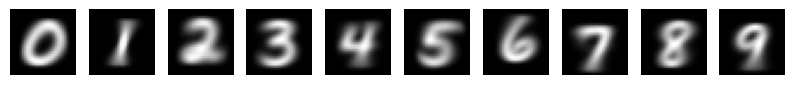

In [24]:
import matplotlib.pyplot as plt

def display_probabilities(P):
    fig, ax = plt.subplots(1,P.shape[0],figsize=(P.shape[0],1))
    for i in range(P.shape[0]):
        ax[i].imshow(P[i].reshape((28,28)),cmap='gray')
        ax[i].axis('off')

display_probabilities(pac)

## 6. MNIST Prediction with Direct Probability Products

The two earlier instance-level implementations are applied across the complete test set.

In [25]:
pred = np.array([
    classify_loop(x, p_class, pac)
    for x in x_test_binary
])
print(pred.shape)

(10000,)


In [26]:
pred_withoutloop = np.array([
    classify_multiply_reduce(x, p_class, pac)
    for x in x_test_binary
])
print(pred_withoutloop.shape)

(10000,)


In [27]:
print((pred == pred_withoutloop).all())

True


### Accuracy of the Two Instance-Level Implementations

In [28]:
print("Accuracy for Naive Bayes  :", np.mean(pred ==y_test))

Accuracy for Naive Bayes  : 0.8458


In [29]:
print("Accuracy for Naive Bayes  without loop(classify):", np.mean(pred_withoutloop ==y_test))

Accuracy for Naive Bayes  without loop(classify): 0.8458


### Batch Product Implementation

A third prediction implementation computes the feature-probability terms across all classes for each test observation and returns the class with the largest normalized probability.

In [30]:
def classify_batch_product(x_test, pc, pac):
    pred = np.zeros(x_test.shape[0], dtype=int)
    probs = np.zeros((x_test.shape[0], 10))

    for i, x in enumerate(x_test):
        p = pac * x + (1 - pac) * (1 - x)
        m = np.prod(p, axis=1)
        probs[i] = m * pc

    probs = probs / np.sum(probs, axis=1).reshape(-1, 1)
    pred = np.argmax(probs, axis=1)
    return pred


In [31]:
pc = p_class
pred_batch = classify_batch_product(x_test_binary, pc, pac)
accuracy = accuracy_score(y_test, pred_batch)
print(f'Accuracy = {accuracy:.4}')
print(confusion_matrix(y_test, pred_batch))

Accuracy = 0.8458
[[ 893    0    4    5    1   33   22    1   21    0]
 [   0 1082   11    4    0   11    5    0   22    0]
 [  17   12  852   31   20    4   25   15   53    3]
 [   3   15   35  853    0   14    8   17   44   21]
 [   1    7    8    1  801    3   19    3   16  123]
 [  22    8    5  122   21  640   19    8   26   21]
 [  13   16   16    2   11   34  860    0    6    0]
 [   1   28   15    5   14    1    1  866   29   68]
 [  15   23   12   74   13   23   12    6  760   36]
 [  10   13    6    9   69    9    0   24   18  851]]


## 7. Numerical Stability

Directly multiplying hundreds of probabilities creates two important issues.

### Zero Conditional Probabilities

If an attribute value has probability zero for a class, the product for that class becomes zero. This can eliminate a class completely even when the remaining evidence is informative.

### Floating-Point Underflow

Products of many values below 1 can become extremely small. With 784 MNIST attributes, even moderately large probabilities can shrink rapidly:

In [32]:
print(0.99**784)

0.00037843610548752557


In [33]:
print(0.9**784)

1.3369876648013631e-36


In [34]:
print(0.5**784)

9.828413039546407e-237


In [35]:
print(0.25**784)

0.0


### Stabilizing the Calculation

Two techniques are retained from the source implementation:

**Smoothing:** clip conditional probabilities away from exactly 0 and 1.

**Log probabilities:** replace products with sums of logarithms:

```text
log(A * B * C * ...) = log(A) + log(B) + log(C) + ...
```

The maximizing class is unchanged because:

```text
argmax(p) = argmax(log(p))
```

In [36]:
s = 1e-10
pac = np.clip(pac, s, 1-s)

### Log-Probability Classifier

In [37]:
def classify_log_probabilities(x_test, pc, pac):
    pred = np.zeros(x_test.shape[0], dtype=int)
    probs = np.zeros((x_test.shape[0], 10))

    pac_log = np.log(pac)
    pac_minus_log = np.log(1 - pac)
    pc_log = np.log(pc)

    for i, x in enumerate(x_test):
        p = pac_log * x + pac_minus_log * (1 - x)
        m = np.sum(p, axis=1)
        probs[i] = m + pc_log

    probs = np.exp(probs)
    probs = probs / np.sum(probs, axis=1).reshape(-1, 1)
    pred = np.argmax(probs, axis=1)
    return pred


In [38]:
pred_stable = classify_log_probabilities(x_test_binary, pc, pac)
accuracy = accuracy_score(y_test, pred_stable)
print(f'Accuracy = {accuracy:.4}')
print(confusion_matrix(y_test, pred_stable))

Accuracy = 0.8469
[[ 894    0    4    4    1   33   22    1   21    0]
 [   0 1084   10    4    0   11    5    0   21    0]
 [  17   12  853   30   20    4   25   15   53    3]
 [   3   15   35  853    0   14    8   17   44   21]
 [   1    7    5    0  805    3   19    3   16  123]
 [  22    9    5  122   21  640   18    8   26   21]
 [  13   16   15    2   11   34  861    0    6    0]
 [   1   28   15    5   15    0    1  866   30   67]
 [  15   23   12   74   13   22   12    6  762   35]
 [  10   13    6    9   69    9    0   24   18  851]]


## 8. Comparative Results

### Synthetic Binary Example

| Implementation | Predicted Class |
|---|---:|
| Loop-based probability product | 2 |
| Vectorized product formulation | 2 |
| `multiply.reduce` formulation | 2 |

The vectorized formulation also reports the normalized posterior distribution:

`[0.23361808, 0.19261693, 0.57376499]`

### MNIST from Scratch

| Implementation | Saved Test Accuracy |
|---|---:|
| Instance-level loop classifier | 0.8458 |
| Instance-level `multiply.reduce` classifier | 0.8458 |
| Batch direct-product classifier | 0.8469 |
| Smoothed log-probability classifier | **0.8469** |

## 9. Key Findings

- Naive Bayes can be implemented directly from class priors and class-conditional feature probabilities.
- Different loop-based and vectorized formulations produce the same synthetic classification result.
- MNIST can be modeled as a binary-feature problem by thresholding normalized pixel intensities.
- The class priors and conditional probabilities can be estimated with either explicit loops or compact vectorized expressions.
- Class-conditional probability maps provide an interpretable view of the learned digit patterns.
- Direct products of hundreds of probabilities are numerically fragile.
- Smoothing prevents exactly zero feature probabilities, while log probabilities replace unstable products with sums.